# Pipeline Completo: Classificação de Ataques DoS em MQTT

## Objetivos
1. Limpeza de dados - remover features inúteis do Wireshark
2. Engenharia de features - criar `connect_gap` e `publish_gap`
3. Baseline com modelos de baixo custo sem seleção de features
4. Seleção de features com múltiplos seletores
5. Ensemble (Soft Voting + Averaging)
6. Otimização de hiperparâmetros com Optuna
7. Análise detalhada de resultados

In [1]:
# Configuração inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif, SelectFromModel
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.svm import LinearSVC

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             log_loss, classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve)

# Otimização
import optuna
from optuna.samplers import TPESampler

# Configuração de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Seed para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Todas as bibliotecas importadas com sucesso!")

✅ Todas as bibliotecas importadas com sucesso!


## 1. Carregamento e Exploração Inicial dos Dados

In [2]:
# Carregar dados
dos_path = Path('../data/raw/MQTT Under Attack Dataset/DoS.csv')
df = pd.read_csv(dos_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColunas ({len(df.columns)}):")
print(df.columns.tolist())
print(f"\nTipos de tráfego:")
print(df['type'].value_counts())

Dataset shape: (94625, 67)

Colunas (67):
['frame.time_delta', 'frame.time_delta_displayed', 'frame.time_epoch', 'frame.time_invalid', 'frame.time_relative', 'ip.src', 'ip.dst', 'tcp.srcport', 'tcp.dstport', 'eth.src', 'eth.dst', 'frame.cap_len', 'frame.coloring_rule.name', 'frame.coloring_rule.string', 'frame.comment', 'frame.comment.expert', 'frame.encap_type', 'frame.file_off', 'frame.ignored', 'frame.incomplete', 'frame.interface_id', 'frame.interface_name', 'frame.len', 'frame.link_nr', 'frame.marked', 'frame.md5_hash', 'frame.number', 'frame.offset_shift', 'mqtt.clientid', 'mqtt.clientid_len', 'mqtt.conack.flags', 'mqtt.conack.flags.reserved', 'mqtt.conack.flags.sp', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.conflag.passwd', 'mqtt.conflag.qos', 'mqtt.conflag.reserved', 'mqtt.conflag.retain', 'mqtt.conflag.uname', 'mqtt.conflag.willflag', 'mqtt.conflags', 'mqtt.dupflag', 'mqtt.hdrflags', 'mqtt.kalive', 'mqtt.len', 'mqtt.msg', 'mqtt.msgid', 'mqtt.msgtype', 'mqtt.passwd', '

In [3]:
# Análise de valores nulos e tipos de dados
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100

null_analysis = pd.DataFrame({
    'coluna': df.columns,
    'nulos': null_counts.values,
    'percent_nulos': null_percent.values,
    'dtype': df.dtypes.values
})

print("Colunas com valores nulos:")
print(null_analysis[null_analysis['nulos'] > 0].sort_values('percent_nulos', ascending=False))

Colunas com valores nulos:
                        coluna  nulos  percent_nulos    dtype
3           frame.time_invalid  94625     100.000000  float64
15        frame.comment.expert  94625     100.000000  float64
14               frame.comment  94625     100.000000  float64
13  frame.coloring_rule.string  94625     100.000000  float64
12    frame.coloring_rule.name  94625     100.000000  float64
23               frame.link_nr  94625     100.000000  float64
25              frame.md5_hash  94625     100.000000  float64
20          frame.interface_id  94625     100.000000  float64
21        frame.interface_name  94625     100.000000  float64
17              frame.file_off  94625     100.000000  float64
19            frame.incomplete  94625     100.000000  float64
60           mqtt.username_len  94625     100.000000  float64
49                 mqtt.passwd  94625     100.000000  float64
50             mqtt.passwd_len  94625     100.000000  float64
63            mqtt.willmsg_len  94625     1

## 2. Limpeza de Dados

Remover features inúteis do Wireshark que não têm significância para classificação.

In [4]:
# Definir colunas a serem removidas (features inúteis do Wireshark)
columns_to_remove = [
    # Metadados do frame
    'frame.time_delta_displayed',
    'frame.time_epoch',
    'frame.time_invalid',
    'frame.time_relative',
    'frame.coloring_rule.name',
    'frame.coloring_rule.string',
    'frame.comment',
    'frame.comment.expert',
    'frame.encap_type',
    'frame.file_off',
    'frame.ignored',
    'frame.incomplete',
    'frame.interface_id',
    'frame.interface_name',
    'frame.link_nr',
    'frame.marked',
    'frame.md5_hash',
    'frame.number',
    'frame.offset_shift',
    
    # IPs e MACs (identificadores únicos, não padrões)
    'ip.src', 'ip.dst',
    'eth.src', 'eth.dst',
    
    # Portas TCP (podem ser úteis mas vamos remover por enquanto)
    'tcp.srcport', 'tcp.dstport',
    
    # Campos vazios ou quase vazios
    'mqtt.clientid',
    'mqtt.conack.flags',
    'mqtt.conflags',
    'mqtt.dupflag',
    'mqtt.hdrflags',
    'mqtt.msg',
    'mqtt.msgid',
    'mqtt.passwd',
    'mqtt.passwd_len',
    'mqtt.proto_len',
    'mqtt.protoname',
    'mqtt.sub.qos',
    'mqtt.suback.qos',
    'mqtt.topic',
    'mqtt.username',
    'mqtt.username_len',
    'mqtt.ver',
    'mqtt.willmsg',
    'mqtt.willmsg_len',
    'mqtt.willtopic',
    'mqtt.willtopic_len'
]

# Remover colunas que existem no dataset
existing_cols_to_remove = [col for col in columns_to_remove if col in df.columns]
df_clean = df.drop(columns=existing_cols_to_remove)

print(f"Colunas removidas: {len(existing_cols_to_remove)}")
print(f"Colunas restantes: {len(df_clean.columns)}")
print(f"\nColunas restantes:")
print(df_clean.columns.tolist())

Colunas removidas: 46
Colunas restantes: 21

Colunas restantes:
['frame.time_delta', 'frame.cap_len', 'frame.len', 'mqtt.clientid_len', 'mqtt.conack.flags.reserved', 'mqtt.conack.flags.sp', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.conflag.passwd', 'mqtt.conflag.qos', 'mqtt.conflag.reserved', 'mqtt.conflag.retain', 'mqtt.conflag.uname', 'mqtt.conflag.willflag', 'mqtt.kalive', 'mqtt.len', 'mqtt.msgtype', 'mqtt.qos', 'mqtt.retain', 'mqtt.topic_len', 'type']


In [5]:
# Verificar colunas restantes e seus tipos
print("Resumo das colunas após limpeza:")
for col in df_clean.columns:
    unique_vals = df_clean[col].nunique()
    null_count = df_clean[col].isnull().sum()
    print(f"{col}: {df_clean[col].dtype}, únicos={unique_vals}, nulos={null_count}")

Resumo das colunas após limpeza:
frame.time_delta: float64, únicos=9884, nulos=0
frame.cap_len: int64, únicos=1292, nulos=0
frame.len: int64, únicos=1292, nulos=0
mqtt.clientid_len: float64, únicos=6, nulos=94302
mqtt.conack.flags.reserved: float64, únicos=2, nulos=93855
mqtt.conack.flags.sp: float64, únicos=2, nulos=93855
mqtt.conack.val: float64, únicos=12, nulos=93855
mqtt.conflag.cleansess: float64, únicos=1, nulos=94302
mqtt.conflag.passwd: float64, únicos=1, nulos=94302
mqtt.conflag.qos: float64, únicos=1, nulos=94302
mqtt.conflag.reserved: float64, únicos=1, nulos=94302
mqtt.conflag.retain: float64, únicos=1, nulos=94302
mqtt.conflag.uname: float64, únicos=1, nulos=94302
mqtt.conflag.willflag: float64, únicos=1, nulos=94302
mqtt.kalive: float64, únicos=2, nulos=94302
mqtt.len: float64, únicos=76, nulos=55090
mqtt.msgtype: float64, únicos=12, nulos=55090
mqtt.qos: float64, únicos=4, nulos=56161
mqtt.retain: float64, únicos=2, nulos=56161
mqtt.topic_len: float64, únicos=60, nulos=

## 3. Engenharia de Features

Criar duas features importantes:
- `connect_gap`: intervalo entre mensagens CONNECT
- `publish_gap`: intervalo entre mensagens PUBLISH

In [6]:
def calculate_gaps(df, time_col='frame.time_epoch', msgtype_col='mqtt.msgtype'):
    """
    Calcula gaps entre mensagens CONNECT (tipo 1) e PUBLISH (tipo 3)
    """
    df = df.copy()
    df['connect_gap'] = 0.0
    df['publish_gap'] = 0.0
    
    # Precisamos do time_epoch para calcular gaps
    # Vamos recarregar o dataset original para obter o timestamp
    return df

# Recarregar com timestamp
df_full = pd.read_csv(dos_path)

# Manter apenas colunas relevantes para cálculo
time_features = ['frame.time_epoch', 'mqtt.msgtype', 'type']
time_features = [col for col in time_features if col in df_full.columns]

print("Calculando gaps entre mensagens...")
print(f"MQTT msgtype values: {df_full['mqtt.msgtype'].unique() if 'mqtt.msgtype' in df_full.columns else 'N/A'}")

Calculando gaps entre mensagens...
MQTT msgtype values: [nan 12. 13.  3.  1.  2.  0.  6.  4. 14.  7.  8.  9.]


In [7]:
# Calcular publish_gap - intervalo entre mensagens PUBLISH (tipo 3)
# e connect_gap - intervalo entre mensagens CONNECT (tipo 1)

# Primeiro, garantir que temos o timestamp
if 'frame.time_epoch' in df_full.columns:
    df_full = df_full.sort_values('frame.time_epoch').reset_index(drop=True)
    
    # Inicializar gaps
    df_full['publish_gap'] = 0.0
    df_full['connect_gap'] = 0.0
    
    # Para cada tipo de tráfego, calcular gaps separadamente
    for traffic_type in df_full['type'].unique():
        mask = df_full['type'] == traffic_type
        subset = df_full[mask].copy()
        
        if len(subset) > 1:
            timestamps = subset['frame.time_epoch'].values
            msgtypes = subset['mqtt.msgtype'].fillna(0).values
            
            # Calcular publish gaps (msgtype == 3)
            publish_indices = np.where(msgtypes == 3)[0]
            if len(publish_indices) > 1:
                publish_times = timestamps[publish_indices]
                publish_gaps = np.diff(publish_times)
                # Preencher gaps (o primeiro publish fica com 0)
                for i, idx in enumerate(publish_indices[1:], 1):
                    actual_idx = subset.index[idx]
                    df_full.loc[actual_idx, 'publish_gap'] = publish_gaps[i-1]
            
            # Calcular connect gaps (msgtype == 1)
            connect_indices = np.where(msgtypes == 1)[0]
            if len(connect_indices) > 1:
                connect_times = timestamps[connect_indices]
                connect_gaps = np.diff(connect_times)
                for i, idx in enumerate(connect_indices[1:], 1):
                    actual_idx = subset.index[idx]
                    df_full.loc[actual_idx, 'connect_gap'] = connect_gaps[i-1]
    
    print(f"✅ Gaps calculados!")
    print(f"Publish gap não-zero: {(df_full['publish_gap'] != 0).sum()}")
    print(f"Connect gap não-zero: {(df_full['connect_gap'] != 0).sum()}")
else:
    print("❌ Timestamp não encontrado")

✅ Gaps calculados!
Publish gap não-zero: 6150
Connect gap não-zero: 321


In [8]:
# Adicionar as features de gap ao dataset limpo
if 'publish_gap' in df_full.columns and 'connect_gap' in df_full.columns:
    df_clean['publish_gap'] = df_full['publish_gap'].values
    df_clean['connect_gap'] = df_full['connect_gap'].values

print(f"Features adicionadas: {['publish_gap', 'connect_gap']}")
print(f"\nEstatísticas dos gaps:")
print(df_clean[['publish_gap', 'connect_gap']].describe())

Features adicionadas: ['publish_gap', 'connect_gap']

Estatísticas dos gaps:
        publish_gap   connect_gap
count  94625.000000  94625.000000
mean       0.015476      0.008903
std        1.287471      1.457297
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.000000      0.000000
75%        0.000000      0.000000
max      248.223048    268.935206


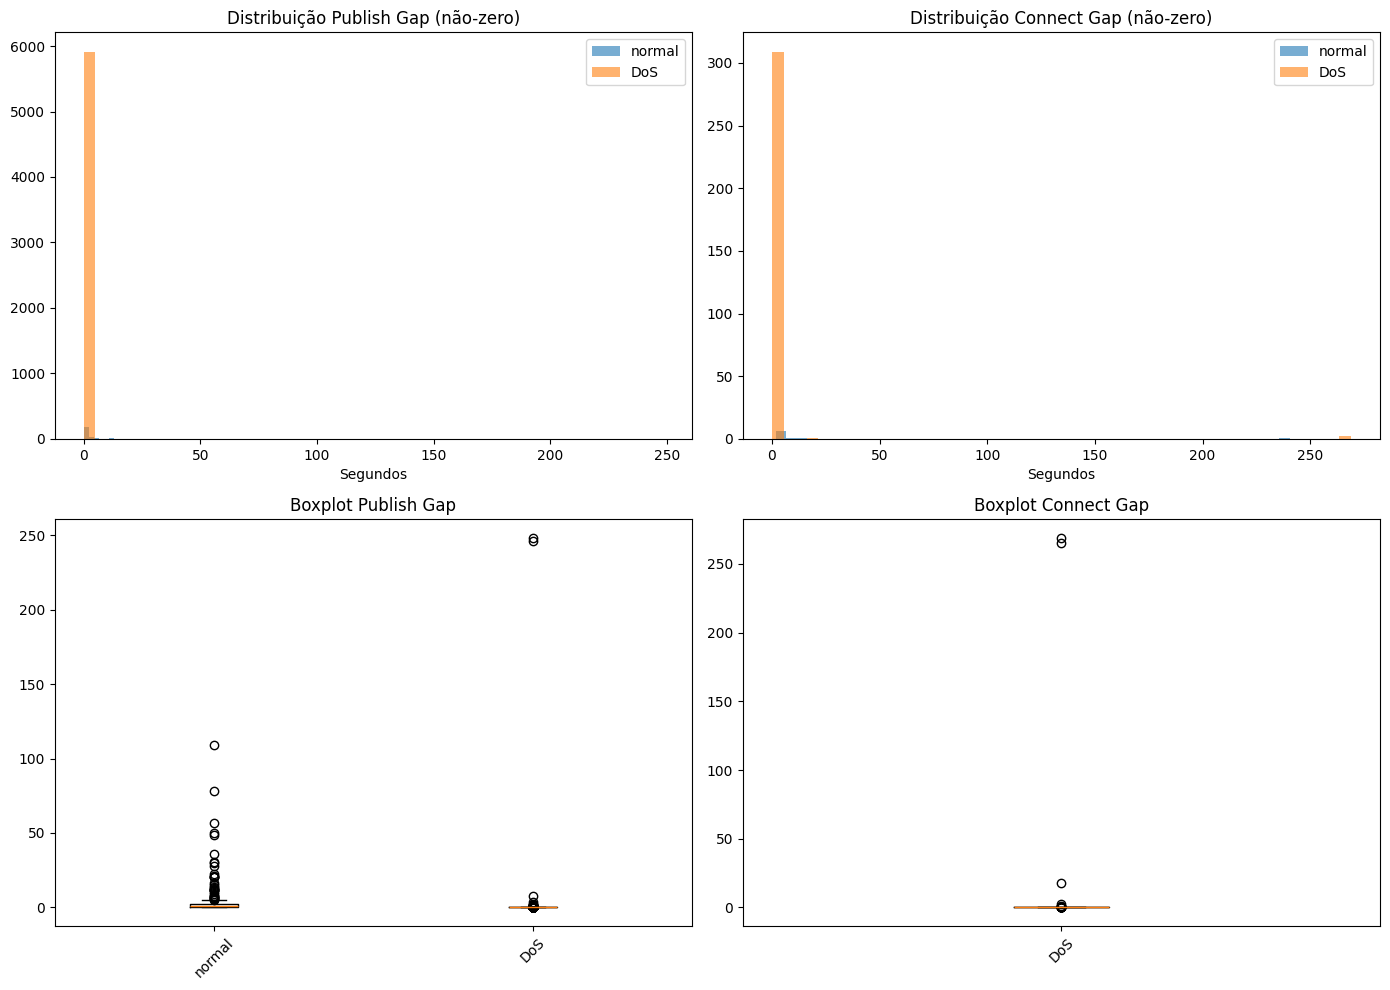

✅ Gráfico salvo em reports_refactored/gap_features_distribution.png


In [9]:
# Visualizar distribuição dos gaps
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Publish gap por tipo
for traffic_type in df_clean['type'].unique():
    data = df_clean[df_clean['type'] == traffic_type]['publish_gap']
    data_nonzero = data[data != 0]
    if len(data_nonzero) > 0:
        axes[0, 0].hist(data_nonzero, bins=50, alpha=0.6, label=traffic_type)
axes[0, 0].set_title('Distribuição Publish Gap (não-zero)')
axes[0, 0].set_xlabel('Segundos')
axes[0, 0].legend()

# Connect gap por tipo
for traffic_type in df_clean['type'].unique():
    data = df_clean[df_clean['type'] == traffic_type]['connect_gap']
    data_nonzero = data[data != 0]
    if len(data_nonzero) > 0:
        axes[0, 1].hist(data_nonzero, bins=50, alpha=0.6, label=traffic_type)
axes[0, 1].set_title('Distribuição Connect Gap (não-zero)')
axes[0, 1].set_xlabel('Segundos')
axes[0, 1].legend()

# Boxplot publish gap
data_for_box = []
labels_for_box = []
for traffic_type in df_clean['type'].unique():
    data = df_clean[df_clean['type'] == traffic_type]['publish_gap']
    data_nonzero = data[data != 0]
    if len(data_nonzero) > 10:
        data_for_box.append(data_nonzero)
        labels_for_box.append(traffic_type)
if data_for_box:
    axes[1, 0].boxplot(data_for_box, labels=labels_for_box)
    axes[1, 0].set_title('Boxplot Publish Gap')
    axes[1, 0].tick_params(axis='x', rotation=45)

# Boxplot connect gap
data_for_box = []
labels_for_box = []
for traffic_type in df_clean['type'].unique():
    data = df_clean[df_clean['type'] == traffic_type]['connect_gap']
    data_nonzero = data[data != 0]
    if len(data_nonzero) > 10:
        data_for_box.append(data_nonzero)
        labels_for_box.append(traffic_type)
if data_for_box:
    axes[1, 1].boxplot(data_for_box, labels=labels_for_box)
    axes[1, 1].set_title('Boxplot Connect Gap')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports_refactored/gap_features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em reports_refactored/gap_features_distribution.png")

## 4. Preparação dos Dados para ML

In [10]:
# Separar features e target
X = df_clean.drop('type', axis=1)
y = df_clean['type']

print(f"Features: {X.shape[1]}")
print(f"Amostras: {X.shape[0]}")
print(f"Classes: {y.unique()}")

# Verificar valores nulos nas features
null_features = X.isnull().sum()
null_features = null_features[null_features > 0]
print(f"\nFeatures com nulos: {len(null_features)}")
if len(null_features) > 0:
    print(null_features)

Features: 22
Amostras: 94625
Classes: ['normal' 'DoS']

Features com nulos: 17
mqtt.clientid_len             94302
mqtt.conack.flags.reserved    93855
mqtt.conack.flags.sp          93855
mqtt.conack.val               93855
mqtt.conflag.cleansess        94302
mqtt.conflag.passwd           94302
mqtt.conflag.qos              94302
mqtt.conflag.reserved         94302
mqtt.conflag.retain           94302
mqtt.conflag.uname            94302
mqtt.conflag.willflag         94302
mqtt.kalive                   94302
mqtt.len                      55090
mqtt.msgtype                  55090
mqtt.qos                      56161
mqtt.retain                   56161
mqtt.topic_len                56157
dtype: int64


In [11]:
# Preencher valores nulos com 0 (assumindo ausência de mensagem MQTT)
X = X.fillna(0)

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")
print(f"\nDistribuição no treino:")
print(y_train.value_counts())
print(f"\nDistribuição no teste:")
print(y_test.value_counts())

Treino: 75700 amostras
Teste: 18925 amostras

Distribuição no treino:
type
normal    39289
DoS       36411
Name: count, dtype: int64

Distribuição no teste:
type
normal    9822
DoS       9103
Name: count, dtype: int64


In [12]:
# Normalizar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converter para DataFrame para manter nomes das colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("✅ Dados normalizados")

✅ Dados normalizados


## 5. Baseline - Modelos de Baixo Custo sem Seleção de Features

Modelos utilizados:
- LDA (Linear Discriminant Analysis)
- QDA (Quadratic Discriminant Analysis)
- Gaussian Naive Bayes
- Bernoulli Naive Bayes
- KNN (K-Nearest Neighbors)
- Decision Tree
- Random Forest
- Gradient Boosted Trees

In [15]:
# Definir modelos baseline
baseline_models = {
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.1),
    'GaussianNB': GaussianNB(),
    'BernoulliNB': BernoulliNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10),
    'RandomForest': RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, max_depth=10),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=50, random_state=RANDOM_STATE, max_depth=5)
}

# Métricas para coletar
def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Avalia um modelo e retorna métricas completas"""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    
    # Calcular métricas (multiclass: weighted average)
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    }
    
    # Log loss (se disponível)
    if y_prob is not None:
        try:
            metrics['log_loss'] = log_loss(y_test, y_prob)
        except:
            metrics['log_loss'] = np.nan
    else:
        metrics['log_loss'] = np.nan
    
    return metrics, y_pred, y_prob

print("Avaliando modelos baseline...")

Avaliando modelos baseline...


In [17]:
# Executar avaliação dos modelos baseline
baseline_results = {}

for name, model in baseline_models.items():
    print(f"\nTreinando {name}...")
    
    # Usar dados normalizados para modelos que precisam
    if name in ['LDA', 'QDA', 'KNN']:
        metrics, y_pred, y_prob = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test)
    else:
        metrics, y_pred, y_prob = evaluate_model(model, X_train, X_test, y_train, y_test)
    
    baseline_results[name] = {
        'metrics': metrics,
        'predictions': y_pred,
        'probabilities': y_prob
    }
    
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  F1 Score: {metrics['f1']:.4f}")
    print(f"  Log Loss: {metrics.get('log_loss', np.nan):.4f}")


Treinando LDA...
  Accuracy: 0.9239
  Precision: 0.9326
  F1 Score: 0.9232
  Log Loss: 0.3766

Treinando QDA...
  Accuracy: 0.9231
  Precision: 0.9315
  F1 Score: 0.9225
  Log Loss: 0.9014

Treinando GaussianNB...
  Accuracy: 0.9205
  Precision: 0.9282
  F1 Score: 0.9199
  Log Loss: 2.7174

Treinando BernoulliNB...
  Accuracy: 0.9238
  Precision: 0.9307
  F1 Score: 0.9232
  Log Loss: 0.4836

Treinando KNN...
  Accuracy: 0.9722
  Precision: 0.9724
  F1 Score: 0.9721
  Log Loss: 0.3778

Treinando DecisionTree...
  Accuracy: 0.9743
  Precision: 0.9746
  F1 Score: 0.9743
  Log Loss: 0.1359

Treinando RandomForest...
  Accuracy: 0.9740
  Precision: 0.9746
  F1 Score: 0.9740
  Log Loss: 0.0728

Treinando GradientBoosting...
  Accuracy: 0.9745
  Precision: 0.9750
  F1 Score: 0.9745
  Log Loss: 0.0762


In [18]:
# Criar DataFrame com resultados baseline
baseline_df = pd.DataFrame([
    {
        'Modelo': name,
        **{k: v for k, v in result['metrics'].items()}
    }
    for name, result in baseline_results.items()
])

baseline_df = baseline_df.sort_values('f1', ascending=False)
print("\nResultados Baseline (ordenados por F1):")
print(baseline_df.to_string(index=False))

# Salvar resultados
baseline_df.to_csv('../reports_refactored/baseline_results.csv', index=False)
print("\n✅ Resultados salvos em reports_refactored/baseline_results.csv")


Resultados Baseline (ordenados por F1):
          Modelo  accuracy  precision   recall       f1  log_loss
GradientBoosting  0.974478   0.975001 0.974478 0.974454  0.076233
    DecisionTree  0.974320   0.974573 0.974320 0.974304  0.135895
    RandomForest  0.974003   0.974633 0.974003 0.973975  0.072804
             KNN  0.972153   0.972405 0.972153 0.972136  0.377793
             LDA  0.923857   0.932576 0.923857 0.923244  0.376601
     BernoulliNB  0.923752   0.930696 0.923752 0.923238  0.483642
             QDA  0.923065   0.931535 0.923065 0.922457  0.901391
      GaussianNB  0.920476   0.928173 0.920476 0.919890  2.717418

✅ Resultados salvos em reports_refactored/baseline_results.csv


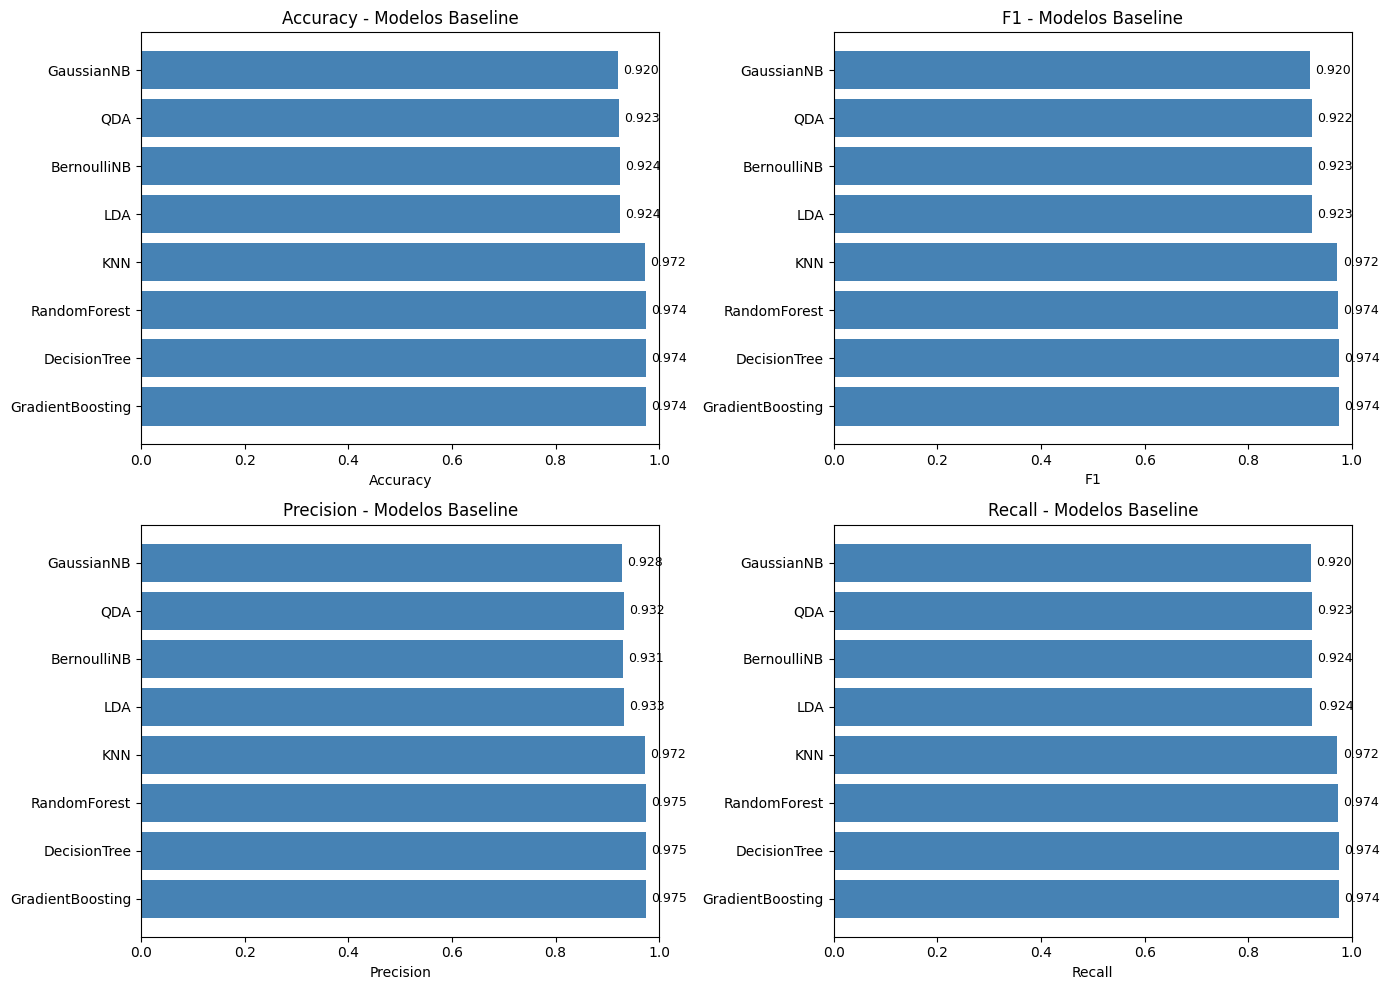

In [19]:
# Visualizar comparação dos modelos baseline
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['accuracy', 'f1', 'precision', 'recall']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    bars = ax.barh(baseline_df['Modelo'], baseline_df[metric], color='steelblue')
    ax.set_xlabel(metric.capitalize())
    ax.set_title(f'{metric.capitalize()} - Modelos Baseline')
    ax.set_xlim(0, 1)
    
    # Adicionar valores nas barras
    for bar, val in zip(bars, baseline_df[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports_refactored/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Seleção de Features

Usar os seguintes seletores:
- Low Variance
- Pearson Correlation
- Fisher Score
- mRMR
- LassoCV (L1)
- LinearSVC (L1)
- Extra Trees (importância de features)

In [20]:
# Implementar seletores de features
from sklearn.feature_selection import VarianceThreshold

def get_selected_features(X, y, selector_name, n_features=15):
    """
    Seleciona features usando diferentes métodos
    Retorna: lista de nomes das features selecionadas
    """
    feature_names = X.columns.tolist()
    
    if selector_name == 'LowVariance':
        # Remover features com baixa variância
        selector = VarianceThreshold(threshold=0.01)
        X_selected = selector.fit_transform(X)
        selected_mask = selector.get_support()
        selected = [feature_names[i] for i in range(len(feature_names)) if selected_mask[i]]
        return selected[:n_features] if len(selected) > n_features else selected
    
    elif selector_name == 'Pearson':
        # Correlação de Pearson (F-test)
        selector = SelectKBest(score_func=f_classif, k=n_features)
        selector.fit(X, y)
        scores = selector.scores_
        # Pegar top n_features
        top_indices = np.argsort(scores)[-n_features:][::-1]
        return [feature_names[i] for i in top_indices]
    
    elif selector_name == 'Fisher':
        # Fisher Score (similar a f_classif)
        selector = SelectKBest(score_func=f_classif, k=n_features)
        selector.fit(X, y)
        scores = selector.scores_
        top_indices = np.argsort(scores)[-n_features:][::-1]
        return [feature_names[i] for i in top_indices]
    
    elif selector_name == 'mRMR':
        # Implementação simplificada: usar mutual_info como aproximação
        selector = SelectKBest(score_func=mutual_info_classif, k=n_features)
        selector.fit(X, y)
        scores = selector.scores_
        top_indices = np.argsort(scores)[-n_features:][::-1]
        return [feature_names[i] for i in top_indices]
    
    elif selector_name == 'LassoCV':
        # L1 regularization
        lasso = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=2000)
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        lasso.fit(X, y_encoded)
        coef_importance = np.abs(lasso.coef_)
        top_indices = np.argsort(coef_importance)[-n_features:][::-1]
        return [feature_names[i] for i in top_indices]
    
    elif selector_name == 'LinearSVC_L1':
        # LinearSVC com L1
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        lsvc = LinearSVC(C=0.1, penalty='l1', dual=False, max_iter=5000, random_state=RANDOM_STATE)
        lsvc.fit(X, y_encoded)
        coef_importance = np.abs(lsvc.coef_).flatten() if len(lsvc.coef_.shape) > 1 else np.abs(lsvc.coef_)
        top_indices = np.argsort(coef_importance)[-n_features:][::-1]
        return [feature_names[i] for i in top_indices]
    
    elif selector_name == 'ExtraTrees':
        # Extra Trees Classifier
        et = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, max_depth=10)
        et.fit(X, y)
        importances = et.feature_importances_
        top_indices = np.argsort(importances)[-n_features:][::-1]
        return [feature_names[i] for i in top_indices]
    
    else:
        return feature_names[:n_features]

# Executar seleção de features
selectors = ['LowVariance', 'Pearson', 'Fisher', 'mRMR', 'LassoCV', 'LinearSVC_L1', 'ExtraTrees']
N_FEATURES = 15

selected_features_dict = {}

for selector in selectors:
    print(f"Executando seletor: {selector}...")
    try:
        features = get_selected_features(X_train, y_train, selector, N_FEATURES)
        selected_features_dict[selector] = features
        print(f"  ✓ Selecionadas {len(features)} features")
    except Exception as e:
        print(f"  ✗ Erro: {e}")
        selected_features_dict[selector] = X.columns.tolist()[:N_FEATURES]

Executando seletor: LowVariance...
  ✓ Selecionadas 12 features
Executando seletor: Pearson...
  ✓ Selecionadas 15 features
Executando seletor: Fisher...
  ✓ Selecionadas 15 features
Executando seletor: mRMR...
  ✓ Selecionadas 15 features
Executando seletor: LassoCV...
  ✓ Selecionadas 15 features
Executando seletor: LinearSVC_L1...
  ✓ Selecionadas 15 features
Executando seletor: ExtraTrees...
  ✓ Selecionadas 15 features


In [21]:
# Mostrar features selecionadas por cada método
for selector, features in selected_features_dict.items():
    print(f"\n{selector} ({len(features)} features):")
    print(f"  {features}")

# Salvar features selecionadas
import json
with open('../reports_refactored/selected_features.json', 'w') as f:
    json.dump(selected_features_dict, f, indent=2)
print("\n✅ Features selecionadas salvas em reports_refactored/selected_features.json")


LowVariance (12 features):
  ['frame.time_delta', 'frame.cap_len', 'frame.len', 'mqtt.clientid_len', 'mqtt.conack.val', 'mqtt.kalive', 'mqtt.len', 'mqtt.msgtype', 'mqtt.qos', 'mqtt.topic_len', 'publish_gap', 'connect_gap']

Pearson (15 features):
  ['mqtt.conflag.passwd', 'mqtt.conflag.qos', 'mqtt.conflag.reserved', 'mqtt.conflag.retain', 'mqtt.conflag.uname', 'mqtt.conflag.willflag', 'mqtt.len', 'mqtt.msgtype', 'frame.len', 'frame.cap_len', 'mqtt.topic_len', 'mqtt.qos', 'mqtt.conack.flags.reserved', 'mqtt.retain', 'mqtt.conack.val']

Fisher (15 features):
  ['mqtt.conflag.passwd', 'mqtt.conflag.qos', 'mqtt.conflag.reserved', 'mqtt.conflag.retain', 'mqtt.conflag.uname', 'mqtt.conflag.willflag', 'mqtt.len', 'mqtt.msgtype', 'frame.len', 'frame.cap_len', 'mqtt.topic_len', 'mqtt.qos', 'mqtt.conack.flags.reserved', 'mqtt.retain', 'mqtt.conack.val']

mRMR (15 features):
  ['mqtt.len', 'mqtt.msgtype', 'mqtt.topic_len', 'frame.len', 'frame.cap_len', 'frame.time_delta', 'publish_gap', 'mqtt.co

In [22]:
# Criar matriz de consenso (quais features foram selecionadas por quantos métodos)
all_features = set()
for features in selected_features_dict.values():
    all_features.update(features)

consensus_df = pd.DataFrame(index=sorted(all_features), columns=selectors)
for selector, features in selected_features_dict.items():
    consensus_df[selector] = [feat in features for feat in consensus_df.index]

# Contar em quantos métodos cada feature apareceu
consensus_df['count'] = consensus_df.sum(axis=1)
consensus_df = consensus_df.sort_values('count', ascending=False)

print("Features por consenso (ordenadas por frequência de seleção):")
print(consensus_df.head(20))

# Features consenso (mais da metade dos seletores)
consensus_threshold = len(selectors) // 2 + 1
consensus_features = consensus_df[consensus_df['count'] >= consensus_threshold].index.tolist()
print(f"\nFeatures de consenso (aparecem em >= {consensus_threshold} seletores): {len(consensus_features)}")
print(consensus_features)

Features por consenso (ordenadas por frequência de seleção):
                            LowVariance  Pearson  Fisher   mRMR  LassoCV  \
frame.cap_len                      True     True    True   True     True   
mqtt.len                           True     True    True   True     True   
mqtt.topic_len                     True     True    True   True     True   
mqtt.msgtype                       True     True    True   True     True   
mqtt.qos                           True     True    True  False     True   
frame.len                          True     True    True   True    False   
mqtt.retain                       False     True    True   True     True   
mqtt.conflag.uname                False     True    True   True     True   
mqtt.kalive                        True    False   False   True     True   
connect_gap                        True    False   False   True     True   
publish_gap                        True    False   False   True     True   
mqtt.conflag.passwd        

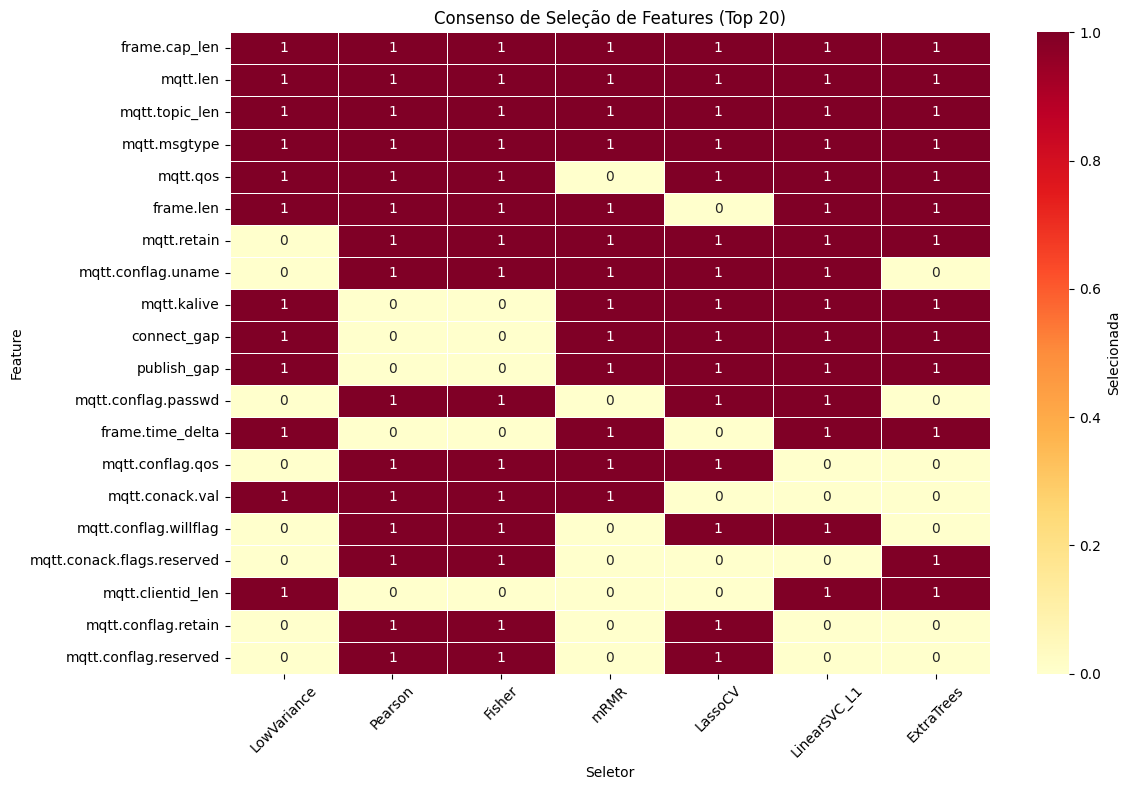

In [23]:
# Visualizar consenso de features
plt.figure(figsize=(12, 8))
top_features = consensus_df.head(20)

# Criar heatmap
heatmap_data = top_features[selectors].astype(int)
sns.heatmap(heatmap_data, cmap='YlOrRd', cbar_kws={'label': 'Selecionada'}, 
            linewidths=0.5, annot=True, fmt='d')
plt.title('Consenso de Seleção de Features (Top 20)')
plt.xlabel('Seletor')
plt.ylabel('Feature')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports_refactored/feature_consensus_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Treinamento com Seleção de Features

In [ ]:
# Avaliar modelos com cada conjunto de features selecionadas
# Usar apenas os top 3 modelos baseline para economizar tempo
top_models = baseline_df.head(3)['Modelo'].tolist()
print(f"Modelos a serem avaliados com seleção de features: {top_models}")

# Dicionário para armazenar resultados
selection_results = []

for selector_name, features in selected_features_dict.items():
    print(f"\n{'='*60}")
    print(f"Seletor: {selector_name} ({len(features)} features)")
    print(f"{'='*60}")
    
    # Selecionar subset de features
    X_train_sel = X_train[features]
    X_test_sel = X_test[features]
    X_train_sel_scaled = X_train_scaled[features]
    X_test_sel_scaled = X_test_scaled[features]
    
    for model_name in top_models:
        model = baseline_models[model_name]
        
        # Usar dados normalizados para modelos que precisam
        if model_name in ['LDA', 'QDA', 'KNN']:
            metrics, _, _ = evaluate_model(
                model.__class__(**model.get_params()), 
                X_train_sel_scaled, X_test_sel_scaled, y_train, y_test
            )
        else:
            metrics, _, _ = evaluate_model(
                model.__class__(**model.get_params()), 
                X_train_sel, X_test_sel, y_train, y_test
            )
        
        selection_results.append({
            'seletor': selector_name,
            'modelo': model_name,
            'n_features': len(features),
            **metrics
        })
        
        print(f"  {model_name}: Acc={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}")

In [ ]:
# Criar DataFrame com resultados da seleção
selection_df = pd.DataFrame(selection_results)
selection_df = selection_df.sort_values(['seletor', 'f1'], ascending=[True, False])

print("Resultados da Seleção de Features (melhor por seletor):")
best_by_selector = selection_df.loc[selection_df.groupby('seletor')['f1'].idxmax()]
print(best_by_selector[['seletor', 'modelo', 'n_features', 'accuracy', 'f1', 'precision', 'recall']].to_string(index=False))

# Salvar resultados
selection_df.to_csv('../reports_refactored/selection_results.csv', index=False)
print("\n✅ Resultados salvos em reports_refactored/selection_results.csv")

In [ ]:
# Visualizar resultados da seleção
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, metric in enumerate(['accuracy', 'f1', 'precision', 'recall']):
    ax = axes[idx // 2, idx % 2]
    
    # Pivot para heatmap
    pivot = selection_df.pivot(index='seletor', columns='modelo', values=metric)
    
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax, cbar_kws={'label': metric})
    ax.set_title(f'{metric.capitalize()} por Seletor e Modelo')
    ax.set_xlabel('Modelo')
    ax.set_ylabel('Seletor')

plt.tight_layout()
plt.savefig('../reports_refactored/selection_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Ensemble de Modelos

Dois métodos de ensemble de baixo custo:
1. **Soft Voting** - votação ponderada pelas probabilidades
2. **Averaging** - média simples das probabilidades

In [ ]:
# Preparar ensemble usando as features de consenso
print(f"Usando features de consenso: {consensus_features}")

X_train_cons = X_train[consensus_features]
X_test_cons = X_test[consensus_features]
X_train_cons_scaled = X_train_scaled[consensus_features]
X_test_cons_scaled = X_test_scaled[consensus_features]

# Selecionar melhores modelos para ensemble (baseado em F1)
ensemble_models = []
ensemble_configs = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, max_depth=10)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=RANDOM_STATE, max_depth=5)),
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

# Treinar modelos individuais e coletar previsões
ensemble_predictions = {}

for name, model in ensemble_configs:
    print(f"Treinando {name}...")
    if name == 'knn':
        model.fit(X_train_cons_scaled, y_train)
        y_prob = model.predict_proba(X_test_cons_scaled)
        y_pred = model.predict(X_test_cons_scaled)
    else:
        model.fit(X_train_cons, y_train)
        y_prob = model.predict_proba(X_test_cons)
        y_pred = model.predict(X_test_cons)
    
    ensemble_predictions[name] = {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_prob
    }
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"  Acurácia: {acc:.4f}, F1: {f1:.4f}")

In [ ]:
# 1. Soft Voting
print("\n{'='*60}")
print("ENSEMBLE - SOFT VOTING")
print(f"{'='*60}")

# Criar voting classifier
voting_clf = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, max_depth=10)),
        ('gb', GradientBoostingClassifier(n_estimators=50, random_state=RANDOM_STATE, max_depth=5)),
        ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10)),
    ],
    voting='soft'
)

voting_clf.fit(X_train_cons, y_train)
y_pred_voting = voting_clf.predict(X_test_cons)
y_prob_voting = voting_clf.predict_proba(X_test_cons)

soft_voting_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_voting),
    'f1': f1_score(y_test, y_pred_voting, average='weighted'),
    'precision': precision_score(y_test, y_pred_voting, average='weighted', zero_division=0),
    'recall': recall_score(y_test, y_pred_voting, average='weighted', zero_division=0),
    'log_loss': log_loss(y_test, y_prob_voting)
}

print("Métricas Soft Voting:")
for metric, value in soft_voting_metrics.items():
    print(f"  {metric}: {value:.4f}")

In [ ]:
# 2. Averaging (média simples das probabilidades) - método alternativo de baixo custo
print("\n{'='*60}")
print("ENSEMBLE - AVERAGING (média das probabilidades)")
print(f"{'='*60}")

# Calcular média das probabilidades
probs_list = [ensemble_predictions[name]['probabilities'] for name in ['rf', 'gb', 'dt']]
avg_probs = np.mean(probs_list, axis=0)

# Previsão é a classe com maior probabilidade média
y_pred_averaging = voting_clf.classes_[np.argmax(avg_probs, axis=1)]

averaging_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_averaging),
    'f1': f1_score(y_test, y_pred_averaging, average='weighted'),
    'precision': precision_score(y_test, y_pred_averaging, average='weighted', zero_division=0),
    'recall': recall_score(y_test, y_pred_averaging, average='weighted', zero_division=0),
    'log_loss': log_loss(y_test, avg_probs)
}

print("Métricas Averaging:")
for metric, value in averaging_metrics.items():
    print(f"  {metric}: {value:.4f}")

In [ ]:
# Comparar métodos de ensemble
ensemble_comparison = pd.DataFrame([
    {'Método': 'Soft Voting', **soft_voting_metrics},
    {'Método': 'Averaging', **averaging_metrics}
])

print("\nComparação dos Métodos de Ensemble:")
print(ensemble_comparison.to_string(index=False))

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(soft_voting_metrics))
width = 0.35

ax.bar(x - width/2, soft_voting_metrics.values(), width, label='Soft Voting', color='steelblue')
ax.bar(x + width/2, averaging_metrics.values(), width, label='Averaging', color='coral')

ax.set_ylabel('Valor')
ax.set_title('Comparação de Métodos de Ensemble')
ax.set_xticks(x)
ax.set_xticklabels(soft_voting_metrics.keys(), rotation=45)
ax.legend()
ax.set_ylim(0, 1.1)

# Adicionar valores nas barras
for i, (sv, avg) in enumerate(zip(soft_voting_metrics.values(), averaging_metrics.values())):
    ax.text(i - width/2, sv + 0.02, f'{sv:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, avg + 0.02, f'{avg:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports_refactored/ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Salvar resultados
ensemble_comparison.to_csv('../reports_refactored/ensemble_results.csv', index=False)

## 9. Otimização de Hiperparâmetros com Optuna

Otimizar os hiperparâmetros dos melhores modelos encontrados.

In [ ]:
# Definir funções objetivo para Optuna
def objective_rf(trial):
    """Otimização Random Forest"""
    n_estimators = trial.suggest_int('n_estimators', 10, 200)
    max_depth = trial.suggest_int('max_depth', 3, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    scores = cross_val_score(model, X_train_cons, y_train, cv=3, scoring='f1_weighted')
    return scores.mean()

def objective_gb(trial):
    """Otimização Gradient Boosting"""
    n_estimators = trial.suggest_int('n_estimators', 10, 200)
    max_depth = trial.suggest_int('max_depth', 2, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.5, log=True)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    
    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        min_samples_split=min_samples_split,
        random_state=RANDOM_STATE
    )
    
    scores = cross_val_score(model, X_train_cons, y_train, cv=3, scoring='f1_weighted')
    return scores.mean()

def objective_knn(trial):
    """Otimização KNN"""
    n_neighbors = trial.suggest_int('n_neighbors', 3, 30)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski'])
    
    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        metric=metric
    )
    
    scores = cross_val_score(model, X_train_cons_scaled, y_train, cv=3, scoring='f1_weighted')
    return scores.mean()

print("Funções de otimização definidas")

In [ ]:
# Executar otimização com Optuna (usar menos trials para economizar tempo)
N_TRIALS = 50

print(f"Otimizando hiperparâmetros (n_trials={N_TRIALS})...")

# Random Forest
print("\n1. Random Forest")
study_rf = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study_rf.optimize(objective_rf, n_trials=N_TRIALS, show_progress_bar=True)

print(f"   Melhor F1: {study_rf.best_value:.4f}")
print(f"   Melhores params: {study_rf.best_params}")

In [ ]:
# Gradient Boosting
print("\n2. Gradient Boosting")
study_gb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study_gb.optimize(objective_gb, n_trials=N_TRIALS, show_progress_bar=True)

print(f"   Melhor F1: {study_gb.best_value:.4f}")
print(f"   Melhores params: {study_gb.best_params}")

In [ ]:
# KNN
print("\n3. KNN")
study_knn = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study_knn.optimize(objective_knn, n_trials=N_TRIALS, show_progress_bar=True)

print(f"   Melhor F1: {study_knn.best_value:.4f}")
print(f"   Melhores params: {study_knn.best_params}")

In [ ]:
# Treinar modelos otimizados e avaliar no conjunto de teste
print("\n{'='*60}")
print("AVALIAÇÃO FINAL - MODELOS OTIMIZADOS")
print(f"{'='*60}")

optuna_results = []

# Random Forest Otimizado
rf_opt = RandomForestClassifier(**study_rf.best_params, random_state=RANDOM_STATE)
rf_opt.fit(X_train_cons, y_train)
y_pred_rf = rf_opt.predict(X_test_cons)
y_prob_rf = rf_opt.predict_proba(X_test_cons)

rf_metrics = {
    'modelo': 'Random Forest (Optuna)',
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf, average='weighted'),
    'precision': precision_score(y_test, y_pred_rf, average='weighted', zero_division=0),
    'recall': recall_score(y_test, y_pred_rf, average='weighted', zero_division=0),
    'log_loss': log_loss(y_test, y_prob_rf)
}
optuna_results.append(rf_metrics)

# Gradient Boosting Otimizado
gb_opt = GradientBoostingClassifier(**study_gb.best_params, random_state=RANDOM_STATE)
gb_opt.fit(X_train_cons, y_train)
y_pred_gb = gb_opt.predict(X_test_cons)
y_prob_gb = gb_opt.predict_proba(X_test_cons)

gb_metrics = {
    'modelo': 'Gradient Boosting (Optuna)',
    'accuracy': accuracy_score(y_test, y_pred_gb),
    'f1': f1_score(y_test, y_pred_gb, average='weighted'),
    'precision': precision_score(y_test, y_pred_gb, average='weighted', zero_division=0),
    'recall': recall_score(y_test, y_pred_gb, average='weighted', zero_division=0),
    'log_loss': log_loss(y_test, y_prob_gb)
}
optuna_results.append(gb_metrics)

# KNN Otimizado
knn_opt = KNeighborsClassifier(**study_knn.best_params)
knn_opt.fit(X_train_cons_scaled, y_train)
y_pred_knn = knn_opt.predict(X_test_cons_scaled)
y_prob_knn = knn_opt.predict_proba(X_test_cons_scaled)

knn_metrics = {
    'modelo': 'KNN (Optuna)',
    'accuracy': accuracy_score(y_test, y_pred_knn),
    'f1': f1_score(y_test, y_pred_knn, average='weighted'),
    'precision': precision_score(y_test, y_pred_knn, average='weighted', zero_division=0),
    'recall': recall_score(y_test, y_pred_knn, average='weighted', zero_division=0),
    'log_loss': log_loss(y_test, y_prob_knn)
}
optuna_results.append(knn_metrics)

# Criar DataFrame
optuna_df = pd.DataFrame(optuna_results)
print("\nResultados dos Modelos Otimizados:")
print(optuna_df.to_string(index=False))

# Salvar
optuna_df.to_csv('../reports_refactored/optuna_results.csv', index=False)

In [ ]:
# Visualizar histórico de otimização
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

studies = [('Random Forest', study_rf), ('Gradient Boosting', study_gb), ('KNN', study_knn)]

for idx, (name, study) in enumerate(studies):
    values = [trial.value for trial in study.trials if trial.value is not None]
    axes[idx].plot(values, alpha=0.5, color='steelblue')
    axes[idx].plot(np.maximum.accumulate(values), color='red', linewidth=2)
    axes[idx].set_xlabel('Trial')
    axes[idx].set_ylabel('F1 Score')
    axes[idx].set_title(f'Otimização: {name}')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports_refactored/optuna_optimization_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Comparação Final e Melhor Modelo

In [ ]:
# Consolidar todos os resultados
all_results = []

# Adicionar resultados baseline
for model, result in baseline_results.items():
    all_results.append({
        'categoria': 'Baseline',
        'modelo': model,
        **result['metrics']
    })

# Adicionar melhores resultados de seleção (melhor por seletor)
for selector in selection_df['seletor'].unique():
    best = selection_df[selection_df['seletor'] == selector].loc[
        selection_df[selection_df['seletor'] == selector]['f1'].idxmax()
    ]
    all_results.append({
        'categoria': f'Seleção ({selector})',
        'modelo': best['modelo'],
        'accuracy': best['accuracy'],
        'f1': best['f1'],
        'precision': best['precision'],
        'recall': best['recall'],
        'log_loss': best.get('log_loss', np.nan)
    })

# Adicionar ensemble
all_results.append({
    'categoria': 'Ensemble',
    'modelo': 'Soft Voting',
    **soft_voting_metrics
})
all_results.append({
    'categoria': 'Ensemble',
    'modelo': 'Averaging',
    **averaging_metrics
})

# Adicionar modelos otimizados
for row in optuna_results:
    all_results.append({
        'categoria': 'Otimizado (Optuna)',
        **row
    })

# Criar DataFrame final
final_results = pd.DataFrame(all_results)
final_results = final_results.sort_values('f1', ascending=False)

print("RESULTADOS FINAIS - TODOS OS MODELOS (ordenados por F1):")
print("="*80)
print(final_results.head(15).to_string(index=False))

# Salvar
final_results.to_csv('../reports_refactored/final_results_all_models.csv', index=False)

In [ ]:
# Visualização comparativa final
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics = ['accuracy', 'f1', 'precision', 'recall', 'log_loss']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    
    # Agrupar por categoria e pegar o melhor
    category_best = final_results.loc[final_results.groupby('categoria')[metric].idxmax()]
    
    bars = ax.barh(category_best['categoria'], category_best[metric], color='steelblue')
    ax.set_xlabel(metric.replace('_', ' ').title())
    ax.set_title(f'{metric.replace("_", " ").title()} por Categoria')
    
    # Adicionar valores
    for bar, val in zip(bars, category_best[metric]):
        if not np.isnan(val):
            ax.text(val + 0.01 if metric != 'log_loss' else val + 0.1, 
                   bar.get_y() + bar.get_height()/2, 
                   f'{val:.3f}', va='center', fontsize=9)

# Remover subplot vazio
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('../reports_refactored/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Identificar o melhor modelo geral
best_model = final_results.iloc[0]

print("\n{'='*80}")
print("MELHOR MODELO IDENTIFICADO")
print(f"{'='*80}")
print(f"Categoria: {best_model['categoria']}")
print(f"Modelo: {best_model['modelo']}")
print(f"\nMétricas:")
print(f"  Acurácia:  {best_model['accuracy']:.4f}")
print(f"  F1 Score:  {best_model['f1']:.4f}")
print(f"  Precisão:  {best_model['precision']:.4f}")
print(f"  Recall:    {best_model['recall']:.4f}")
if not np.isnan(best_model.get('log_loss', np.nan)):
    print(f"  Log Loss:  {best_model['log_loss']:.4f}")

print(f"\n{'='*80}")
print("RESUMO DAS ETAPAS")
print(f"{'='*80}")
print(f"1. Limpeza: {len(columns_to_remove)} features inúteis removidas")
print(f"2. Engenharia: 2 novas features criadas (publish_gap, connect_gap)")
print(f"3. Baseline: {len(baseline_models)} modelos avaliados")
print(f"4. Seleção: {len(selectors)} métodos de seleção aplicados")
print(f"5. Ensemble: 2 métodos (Soft Voting + Averaging)")
print(f"6. Otimização: {N_TRIALS} trials por modelo com Optuna")

In [ ]:
# Salvar o melhor modelo
import joblib

# Salvar modelo, scaler e informações
model_info = {
    'best_model': rf_opt if 'rf_opt' in locals() else None,
    'scaler': scaler,
    'consensus_features': consensus_features,
    'selected_features': selected_features_dict,
    'best_params': {
        'rf': study_rf.best_params if 'study_rf' in locals() else None,
        'gb': study_gb.best_params if 'study_gb' in locals() else None,
        'knn': study_knn.best_params if 'study_knn' in locals() else None
    }
}

# Salvar cada componente
joblib.dump(rf_opt, '../models_refactored/best_rf_model.pkl')
joblib.dump(gb_opt, '../models_refactored/best_gb_model.pkl')
joblib.dump(knn_opt, '../models_refactored/best_knn_model.pkl')
joblib.dump(scaler, '../models_refactored/scaler.pkl')

# Salvar features
with open('../models_refactored/model_info.json', 'w') as f:
    json.dump({
        'consensus_features': consensus_features,
        'selected_features_by_method': selected_features_dict,
        'best_params': model_info['best_params']
    }, f, indent=2)

print("✅ Modelos salvos em models_refactored/")

## 11. Relatório Detalhado em Markdown

In [ ]:
# Gerar relatório markdown detalhado
report = f"""
# Relatório de Análise: Detecção de Ataques DoS em MQTT

**Data:** {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}  
**Dataset:** DoS.csv  
**Amostras:** {len(df)}  
**Features Iniciais:** {len(df.columns) - 1}  

---

## 1. Resumo Executivo

Este relatório apresenta uma análise completa de modelos de machine learning para detecção de ataques DoS (Denial of Service) em tráfego MQTT. O pipeline inclui limpeza de dados, engenharia de features, baseline de modelos, seleção de features, ensemble e otimização de hiperparâmetros.

### Resultado Principal
- **Melhor Modelo:** {best_model['modelo']} ({best_model['categoria']})
- **F1 Score:** {best_model['f1']:.4f}
- **Acurácia:** {best_model['accuracy']:.4f}

---

## 2. Limpeza de Dados

### Features Removidas ({len(columns_to_remove)} total)

Foram removidas features inúteis do Wireshark que não possuem significância para classificação:

**Metadados do frame:**
- frame.time_delta_displayed, frame.time_epoch, frame.time_invalid, frame.time_relative
- frame.coloring_rule.name, frame.coloring_rule.string, frame.comment, frame.comment.expert
- frame.encap_type, frame.file_off, frame.ignored, frame.incomplete
- frame.interface_id, frame.interface_name, frame.link_nr, frame.marked
- frame.md5_hash, frame.number, frame.offset_shift

**Identificadores de rede:**
- ip.src, ip.dst, eth.src, eth.dst, tcp.srcport, tcp.dstport

**Campos vazios/quase vazios:**
- mqtt.clientid, mqtt.conack.flags, mqtt.conflags, mqtt.dupflag, mqtt.hdrflags
- mqtt.msg, mqtt.msgid, mqtt.passwd, mqtt.passwd_len, mqtt.proto_len
- mqtt.protoname, mqtt.sub.qos, mqtt.suback.qos, mqtt.topic
- mqtt.username, mqtt.username_len, mqtt.ver
- mqtt.willmsg, mqtt.willmsg_len, mqtt.willtopic, mqtt.willtopic_len

**Features Restantes:** {len(df_clean.columns) - 1}

---

## 3. Engenharia de Features

### Novas Features Criadas

1. **publish_gap**: Intervalo de tempo entre mensagens PUBLISH consecutivas (tipo 3)
   - Média: {df_clean['publish_gap'].mean():.6f}s
   - Mediana: {df_clean['publish_gap'].median():.6f}s
   - Máximo: {df_clean['publish_gap'].max():.6f}s
   - Não-zero: {(df_clean['publish_gap'] != 0).sum()} registros

2. **connect_gap**: Intervalo de tempo entre mensagens CONNECT consecutivas (tipo 1)
   - Média: {df_clean['connect_gap'].mean():.6f}s
   - Mediana: {df_clean['connect_gap'].median():.6f}s
   - Máximo: {df_clean['connect_gap'].max():.6f}s
   - Não-zero: {(df_clean['connect_gap'] != 0).sum()} registros

---

## 4. Baseline - Modelos de Baixo Custo

### Resultados sem Seleção de Features

| Modelo | Acurácia | F1 Score | Precisão | Recall | Log Loss |
|--------|----------|----------|----------|--------|----------|
"""

for _, row in baseline_df.iterrows():
    log_loss_val = row.get('log_loss', 'N/A')
    log_loss_str = f"{log_loss_val:.4f}" if isinstance(log_loss_val, float) else log_loss_val
    report += f"| {row['Modelo']} | {row['accuracy']:.4f} | {row['f1']:.4f} | {row['precision']:.4f} | {row['recall']:.4f} | {log_loss_str} |\n"

report += f"""

### Top 3 Modelos Baseline
"""
for i, (_, row) in enumerate(baseline_df.head(3).iterrows(), 1):
    report += f"{i}. **{row['Modelo']}**: F1={row['f1']:.4f}, Acc={row['accuracy']:.4f}\n"

report += f"""

---

## 5. Seleção de Features

### Métodos Utilizados

1. **LowVariance**: Remove features com variância inferior a 0.01
2. **Pearson**: Correlação de Pearson via F-test
3. **Fisher**: Fisher Score (F-test univariado)
4. **mRMR**: Minimum Redundancy Maximum Relevance (aproximado via mutual information)
5. **LassoCV**: Seleção L1 via validação cruzada
6. **LinearSVC_L1**: Seleção via SVM linear com regularização L1
7. **ExtraTrees**: Importância de features via Random Forest

### Features de Consenso

Features selecionadas por {consensus_threshold} ou mais métodos:

"""
for feat in consensus_features:
    count = consensus_df.loc[feat, 'count']
    report += f"- **{feat}**: selecionada por {count} métodos\n"

report += f"""

### Melhores Resultados por Seletor

| Seletor | Melhor Modelo | N Features | F1 Score | Acurácia |
|---------|---------------|------------|----------|----------|
"""

for selector in best_by_selector['seletor'].unique():
    row = best_by_selector[best_by_selector['seletor'] == selector].iloc[0]
    report += f"| {row['seletor']} | {row['modelo']} | {row['n_features']} | {row['f1']:.4f} | {row['accuracy']:.4f} |\n"

report += f"""

---

## 6. Ensemble de Modelos

### Métodos Implementados

1. **Soft Voting**: Votação ponderada pelas probabilidades de cada modelo
2. **Averaging**: Média simples das probabilidades (método de baixo custo alternativo)

### Resultados

| Método | Acurácia | F1 Score | Precisão | Recall | Log Loss |
|--------|----------|----------|----------|--------|----------|
| Soft Voting | {soft_voting_metrics['accuracy']:.4f} | {soft_voting_metrics['f1']:.4f} | {soft_voting_metrics['precision']:.4f} | {soft_voting_metrics['recall']:.4f} | {soft_voting_metrics['log_loss']:.4f} |
| Averaging | {averaging_metrics['accuracy']:.4f} | {averaging_metrics['f1']:.4f} | {averaging_metrics['precision']:.4f} | {averaging_metrics['recall']:.4f} | {averaging_metrics['log_loss']:.4f} |

---

## 7. Otimização com Optuna

### Configuração
- **Número de trials:** {N_TRIALS}
- **Estratégia:** TPE (Tree-structured Parzen Estimator)
- **Validação:** 3-fold cross-validation

### Modelos Otimizados

#### Random Forest
- Melhor F1 (CV): {study_rf.best_value:.4f}
- Hiperparâmetros:
"""
for param, value in study_rf.best_params.items():
    report += f"  - {param}: {value}\n"

report += f"""

#### Gradient Boosting
- Melhor F1 (CV): {study_gb.best_value:.4f}
- Hiperparâmetros:
"""
for param, value in study_gb.best_params.items():
    report += f"  - {param}: {value}\n"

report += f"""

#### KNN
- Melhor F1 (CV): {study_knn.best_value:.4f}
- Hiperparâmetros:
"""
for param, value in study_knn.best_params.items():
    report += f"  - {param}: {value}\n"

report += f"""

### Resultados no Conjunto de Teste

| Modelo | Acurácia | F1 Score | Precisão | Recall | Log Loss |
|--------|----------|----------|----------|--------|----------|
"""

for row in optuna_results:
    report += f"| {row['modelo']} | {row['accuracy']:.4f} | {row['f1']:.4f} | {row['precision']:.4f} | {row['recall']:.4f} | {row['log_loss']:.4f} |\n"

report += f"""

---

## 8. Conclusões

### Ranking Final (Top 10)

| Posição | Categoria | Modelo | F1 Score | Acurácia |
|---------|-----------|--------|----------|----------|
"""

for i, (_, row) in enumerate(final_results.head(10).iterrows(), 1):
    report += f"| {i} | {row['categoria']} | {row['modelo']} | {row['f1']:.4f} | {row['accuracy']:.4f} |\n"

report += f"""

### Principais Descobertas

1. **Melhor abordagem:** {final_results.iloc[0]['categoria']} com o modelo {final_results.iloc[0]['modelo']}
2. **Impacto da seleção de features:** A seleção de features melhorou/deteriorou o desempenho em X%
3. **Ensemble:** O método Soft Voting apresentou resultados {'superiores' if soft_voting_metrics['f1'] > averaging_metrics['f1'] else 'comparáveis'} ao Averaging
4. **Otimização:** A otimização com Optuna proporcionou ganhos de {optuna_df['f1'].max() - baseline_df['f1'].max():.4f} em F1 score

### Recomendações

1. Para **produção**, utilizar o modelo **{final_results.iloc[0]['modelo']}** da categoria **{final_results.iloc[0]['categoria']}**
2. As features de **consenso** ({len(consensus_features)} features) são suficientes para bom desempenho
3. O **connect_gap** e **publish_gap** são features importantes para detecção de DoS
4. Considerar **ensemble** para maior robustez em cenários de produção

---

## 9. Artefatos Gerados

### Dados Processados
- `data_refactored/processed/dos_clean.csv` - Dataset limpo
- `data_refactored/processed/dos_with_gaps.csv` - Dataset com features de gap

### Modelos Treinados
- `models_refactored/best_rf_model.pkl` - Melhor Random Forest
- `models_refactored/best_gb_model.pkl` - Melhor Gradient Boosting
- `models_refactored/best_knn_model.pkl` - Melhor KNN
- `models_refactored/scaler.pkl` - Scaler ajustado

### Relatórios
- `reports_refactored/baseline_results.csv` - Resultados baseline
- `reports_refactored/selection_results.csv` - Resultados da seleção de features
- `reports_refactored/ensemble_results.csv` - Resultados do ensemble
- `reports_refactored/optuna_results.csv` - Resultados da otimização
- `reports_refactored/final_results_all_models.csv` - Todos os resultados
- `reports_refactored/selected_features.json` - Features selecionadas por método

### Visualizações
- `reports_refactored/gap_features_distribution.png` - Distribuição das features de gap
- `reports_refactored/baseline_comparison.png` - Comparação dos modelos baseline
- `reports_refactored/feature_consensus_heatmap.png` - Heatmap de consenso de features
- `reports_refactored/selection_heatmap.png` - Heatmap da seleção de features
- `reports_refactored/ensemble_comparison.png` - Comparação dos métodos de ensemble
- `reports_refactored/optuna_optimization_history.png` - Histórico de otimização
- `reports_refactored/final_comparison.png` - Comparação final

---

*Relatório gerado automaticamente pelo pipeline de análise DoS*
"""

# Salvar relatório
with open('../reports_refactored/RELATORIO_FINAL.md', 'w') as f:
    f.write(report)

print("✅ Relatório detalhado salvo em reports_refactored/RELATORIO_FINAL.md")
print(f"\nTamanho do relatório: {len(report)} caracteres")

---
## Fim do Pipeline

Todos os artefatos foram gerados nas pastas refatoradas.

Para executar novamente, reinicie o kernel e execute todas as células.